# pymesh2D: Mesh Generation from XYZ Bathymetry

[![GitHub](https://img.shields.io/badge/GitHub-pymesh2d-blue?logo=github)](https://github.com/GeoOcean/pymesh2d)

This notebook demonstrates how to use **pymesh2D** to generate unstructured triangular meshes from bathymetric data stored in XYZ format. 
`pymesh2D` is a Python-based mesh generator for two-dimensional polygonal geometries, providing Delaunay-based triangulation algorithms.

**Repository:** [https://github.com/GeoOcean/pymesh2d](https://github.com/GeoOcean/pymesh2d)

---

## Table of Contents

1. [Data Loading](#1-loading-xyz-bathymetric-data)
2. [Coastline Extraction](#2-coastline-polygon-extraction)
3. [Polygon Preprocessing](#3-polygon-resampling-and-preparation)
4. [Mesh Generation](#4-mesh-generation-with-delaunay-refinement)
5. [Mesh Quality Optimization](#5-mesh-smoothing-and-quality-control)
6. [Bathymetry Interpolation](#6-bathymetry-interpolation)
7. [Export](#7-export-to-grid-formats)

---

## 1. Loading XYZ Bathymetric Data

Load bathymetric data from an XYZ file (space-separated format with Longitude, Latitude, and Depth columns):


In [1]:
import pandas as pd

dat_path = "Bahia_Sant_5m.xyz"

batimetry = pd.read_csv(dat_path, sep='\s+', header=None, names=["Longitude", "Latitude", "Depth"])

### Visualize the Bathymetry

Let's plot the elevation data using a terrain colormap:

Text(0, 0.5, 'Latitude')

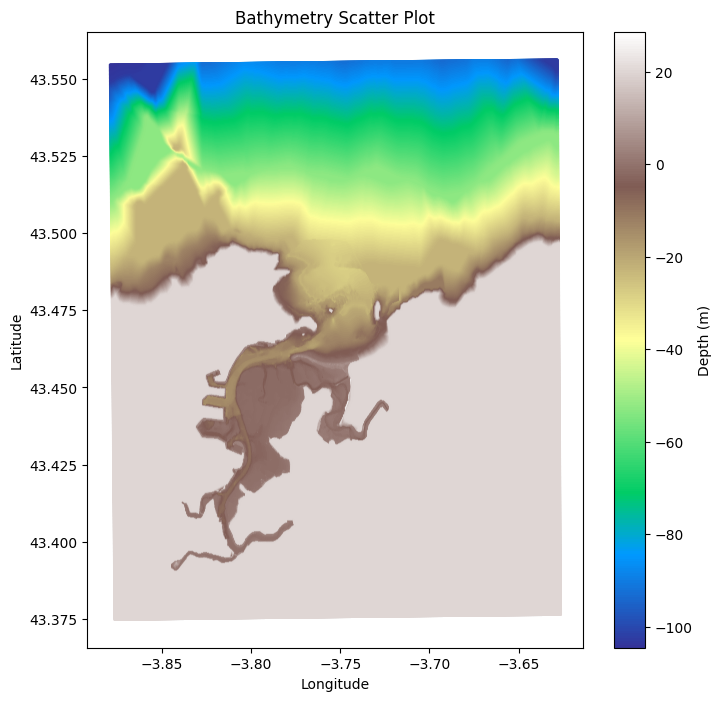

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_title("Bathymetry Scatter Plot")
cbar = plt.colorbar(ax.scatter(batimetry["Longitude"][::10], batimetry["Latitude"][::10], c=batimetry["Depth"][::10], cmap='terrain', s=1/2), ax=ax)
cbar.set_label("Depth (m)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

---

## 2. Coastline Polygon Extraction

Now we extract the coastline by identifying the **zero-elevation contour** (sea level). 
The `getiso_polygone` function extracts polygons where elevation ≤ 0 (i.e., the ocean areas).

In [3]:
import pyproj

crs = pyproj.CRS.from_epsg(4326)

In [6]:
from pymesh2d.geom_util.getiso import getiso_polygone

lon = batimetry["Longitude"]
lat = batimetry["Latitude"]
zdat = batimetry["Depth"]

# Target mesh resolution in meters (raster resolution)
raster_resolution = 75

# Extract ocean polygon (elevation <= 0)
polygone_intersection = getiso_polygone(lon, lat, zdat, zmax=0, grid_res=2000)

### Visualize the Extracted Coastline

Overlay the extracted polygon on the bathymetry:

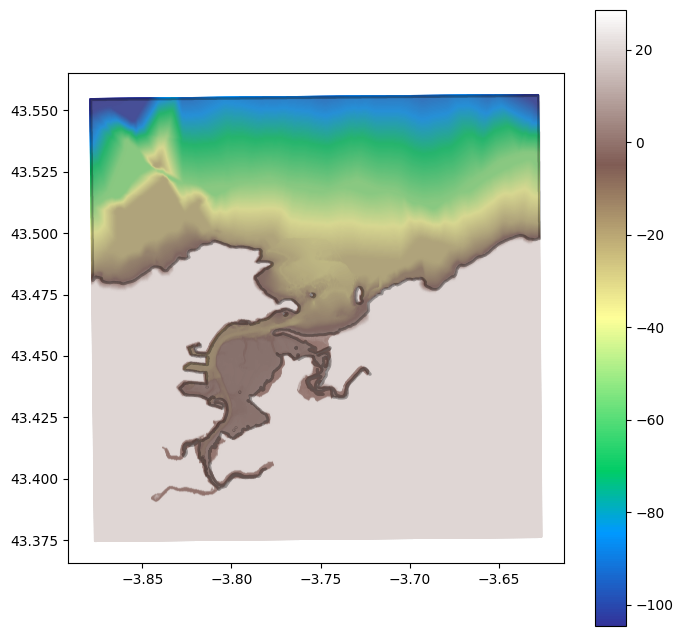

In [7]:
import geopandas as gpd

fig, ax = plt.subplots(figsize=(8, 8))
cbar = plt.colorbar(ax.scatter(batimetry["Longitude"][::10], batimetry["Latitude"][::10], c=batimetry["Depth"][::10], cmap='terrain', s=1/2), ax=ax)
gdf = gpd.GeoDataFrame(geometry=[polygone_intersection], crs=crs)
gdf.plot(ax=ax, facecolor="grey", alpha=0.3, edgecolor="black", linewidth=2);

---

## 3. Polygon Resampling and Preparation

Before mesh generation, we need to:
1. **Reproject** the polygon to UTM coordinates (for accurate distance calculations)
2. **Resample** the polygon vertices to achieve uniform spacing matching our target resolution

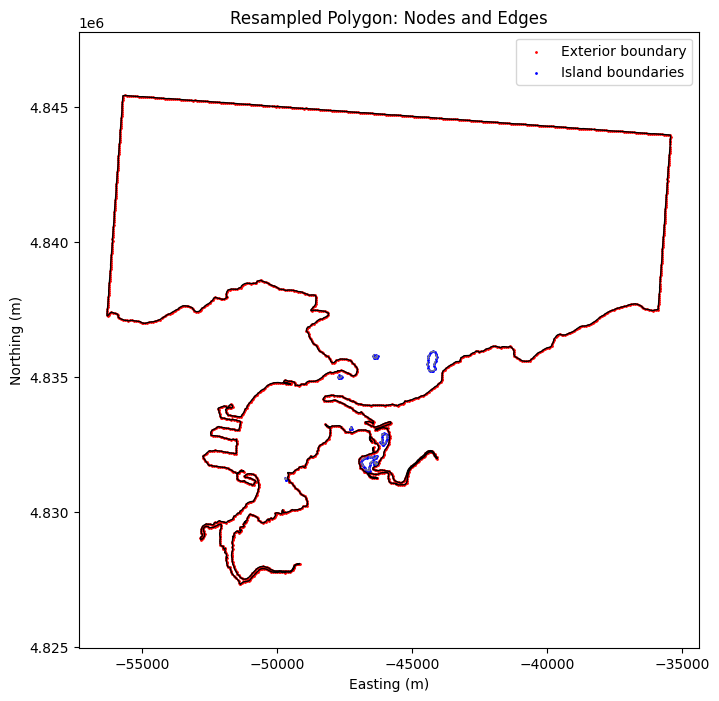

In [8]:
import matplotlib.pyplot as plt

from pymesh2d.geom_util.poly_util import resample_polygon
from pymesh2d.geom_util.proj_util import get_utm_crs_from_crs, reproject_geometry

# Reproject to UTM for metric calculations
polygone_intersection_UTM = reproject_geometry(
    polygone_intersection, crs, get_utm_crs_from_crs(crs)
)

# Resample polygon vertices to target resolution
polygone_intersection_resampled_UTM = resample_polygon(
    polygone_intersection_UTM, raster_resolution
)

# Visualize the resampled polygon
fig, ax = plt.subplots(figsize=(8, 8))

x, y = polygone_intersection_resampled_UTM.exterior.xy
ax.scatter(x, y, color="red", s=1, label="Exterior boundary")
ax.plot(x, y, color="black", lw=1)

for i, hole in enumerate(polygone_intersection_resampled_UTM.interiors):
    xh, yh = hole.xy
    label = "Island boundaries" if i == 0 else None
    ax.scatter(xh, yh, color="blue", s=1, label=label)
    ax.plot(xh, yh, color="gray", linestyle="--", lw=1)

ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_title("Resampled Polygon: Nodes and Edges")
ax.axis("equal")
ax.legend();

### Create Bounding Box and Final Domain

We create a bounding box polygon and intersect it with the coastline to define our final mesh domain:

In [ ]:
from shapely.geometry import Polygon
from pymesh2d.geom_util.poly_util import buffer_area

min_lat = 43.5 # min(lat)
# Create bounding box polygon
poly_bbox = Polygon([
    (min(lon), min_lat),
    (min(lon), max(lat)),
    (max(lon), max(lat)),
    (max(lon), min_lat),
    (min(lon), min_lat),
])

# Reproject to UTM and apply small negative buffer
poly_bbox_UTM = reproject_geometry(poly_bbox, crs, get_utm_crs_from_crs(crs))
poly_bbox_UTM = buffer_area(poly_bbox_UTM, -0.06)

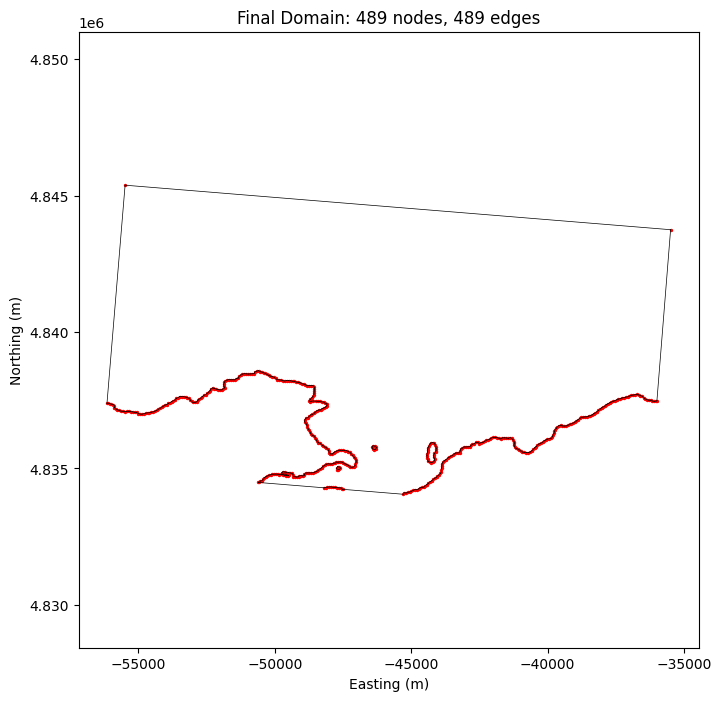

In [ ]:
from pymesh2d.geom_util.poly_util import polygon_to_node_edge

# Compute intersection to get final domain
polygone_final_UTM = polygone_intersection_resampled_UTM.intersection(poly_bbox_UTM)
node, edge = polygon_to_node_edge(polygone_final_UTM)

# Visualize the final domain
fig, ax = plt.subplots(figsize=(8, 8))

for e in edge.astype(int):
    ax.plot(node[e, 0], node[e, 1], "k-", lw=0.5)
ax.scatter(node[:, 0], node[:, 1], color="red", s=2)

ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_title(f"Final Domain: {len(node)} nodes, {len(edge)} edges")
ax.axis("equal");

---

## 4. Mesh Generation with Delaunay Refinement

Now we generate the mesh using **Delaunay refinement**. We also define a **mesh sizing function** (`hfun`) based on wave dispersion characteristics, which controls element sizes based on local water depth.

In [25]:
from pymesh2d.geomesh_util.depth_field import depth_field_from_dat
from pymesh2d.geomesh_util.hfun_dispercion import hfun_wavenumhunt

# Create depth field for mesh sizing function
depth_field = depth_field_from_dat(
    lat, lon, zdat,
    input_crs=crs, 
    output_crs=get_utm_crs_from_crs(crs), 
)

# Define mesh sizing function based on wave dispersion
def hfun(test):
    """Mesh sizing function based on wave characteristics.
    
    Uses the Hunt approximation for wave number to determine
    appropriate element sizes based on water depth.
    """
    return hfun_wavenumhunt(
        test, 
        depth_field, 
        T=60 * 60 * 1,  # Wave period (1 hours)
        N=10,           # Elements per wavelength
        zmin=1,         # Minimum depth
        hmin=raster_resolution  # Minimum element size
    )

In [29]:
from pymesh2d.refine import refine
from pymesh2d.smooth import smooth

# Mesh refinement options
opts = {"kind": "delaunay"}

# Generate initial mesh with Delaunay refinement
vert_UTM, etri, tria, tnum = refine(node, edge, [], opts, hfun)

# Smooth the mesh for better quality
vert_UTM, etri, tria, tnum = smooth(vert_UTM, etri, tria, tnum)


 Refine triangulation...

 -------------------------------------------------------
      |ITER.|          |CDT1(X)|          |CDT2(X)|     
 -------------------------------------------------------
          6                531                493
         10                551                685
         20                572               2700
         30                574               3026
         30                574               3026


 Smooth triangulation...

 -------------------------------------------------------
      |ITER.|          |MOVE(X)|          |DTRI(X)|     
 -------------------------------------------------------
          0               1188               3034
          4                986               2972
          8                229               2974
         12                  0               2974



---

## 5. Mesh Smoothing and Quality Control

After refinement, we analyze mesh quality by computing **circumcenters** and identifying potentially problematic small flow links.

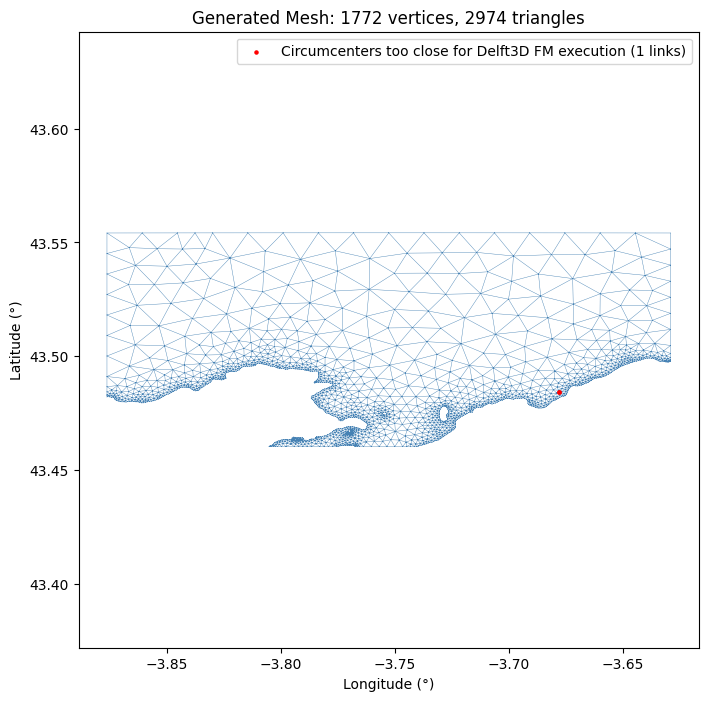

In [30]:
from pymesh2d.geom_util.proj_util import reproject_node
from pymesh2d.mesh_util.tricon import tricon
from pymesh2d.mesh_util.circo import small_flow_centers

# Compute triangle connectivity
edge_cc, _ = tricon(tria, None)

# Find circumcenters and identify small flow links
circumcenters_UTM, nlinktoosmall = small_flow_centers(
    vert_UTM, tria, edge_cc, 
    removesmalllinkstrsh=0.11, 
    conn=None
)

# Reproject back to geographic coordinates
vert = reproject_node(vert_UTM, get_utm_crs_from_crs(crs), crs)
circumcenters = reproject_node(circumcenters_UTM, get_utm_crs_from_crs(crs), crs)

# Visualize the mesh
fig, ax = plt.subplots(figsize=(8, 8))

ax.triplot(vert[:, 0], vert[:, 1], tria[:, 0:3], color="steelblue", lw=0.3)

if nlinktoosmall > 0:
    ax.scatter(circumcenters[:, 0], circumcenters[:, 1], 
               color="red", s=5, zorder=5,
               label=f"Circumcenters too close for Delft3D FM execution ({nlinktoosmall} links)")

ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.set_title(f"Generated Mesh: {len(vert)} vertices, {len(tria)} triangles")
ax.axis("equal")
ax.legend();

### Circumcenter Distance Control for Delft3D FM

For numerical models like **Delft3D FM**, it is essential to control the distance between circumcenters of adjacent triangles. 
Small flow links (i.e., circumcenters that are too close together) can cause numerical instabilities in the hydrodynamic computations.

The `removesmalllinkstrsh` parameter in the smoothing step allows automatic detection and correction of these problematic elements:

In [31]:
# Alternative approach: combine refinement and smoothing with options
opts_refine = {"kind": "delaunay"}
opts_smooth = {"removesmalllinkstrsh": 0.11}

vert_UTM_c, etri_c, tria_c, tnum_c = refine(node, edge, [], opts_refine, hfun)
vert_UTM_c, etri_c, tria_c, tnum_c = smooth(vert_UTM_c, etri_c, tria_c, tnum_c, opts_smooth)


 Refine triangulation...

 -------------------------------------------------------
      |ITER.|          |CDT1(X)|          |CDT2(X)|     
 -------------------------------------------------------
          6                531                493
         10                551                685
         20                572               2700
         30                574               3026
         30                574               3026


 Smooth triangulation...

 -------------------------------------------------------
      |ITER.|          |MOVE(X)|          |DTRI(X)|     
 -------------------------------------------------------
          0               1188               3034
          4                996               2968
          8                244               2968
         12                  2               2968



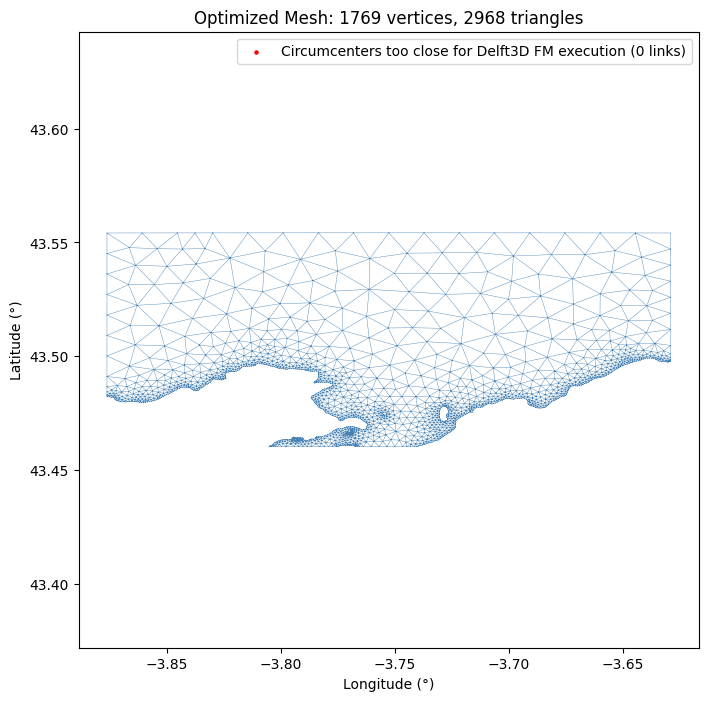

In [32]:
# Analyze the optimized mesh
edge_c, _ = tricon(tria_c, None)

circumcenters_UTM_c, nlinktoosmall_c = small_flow_centers(
    vert_UTM_c, tria_c, edge_c, 
    removesmalllinkstrsh=0.11, 
    conn=None
)

vert_c = reproject_node(vert_UTM_c, get_utm_crs_from_crs(crs), crs)
circumcenters_c = reproject_node(circumcenters_UTM_c, get_utm_crs_from_crs(crs), crs)

# Visualize
fig, ax = plt.subplots(figsize=(8, 8))

ax.triplot(vert_c[:, 0], vert_c[:, 1], tria_c[:, 0:3], color="steelblue", lw=0.3)

ax.scatter(circumcenters_c[:, 0], circumcenters_c[:, 1], 
            color="red", s=5, zorder=5,
            label=f"Circumcenters too close for Delft3D FM execution ({nlinktoosmall_c} links)")

ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.set_title(f"Optimized Mesh: {len(vert_c)} vertices, {len(tria_c)} triangles")
ax.axis("equal")
ax.legend();

---

## 6. Bathymetry Interpolation

Interpolate the elevation values from the XYZ data onto the mesh vertices:

In [33]:
from pymesh2d.geomesh_util.interpolation_mesh import interpolate_from_xyz

# Interpolate bathymetry onto mesh vertices
z = interpolate_from_xyz(lon, lat, zdat, vert, method = "nearest")

---

## 7. Export to Grid Formats

Finally, we export the mesh to various formats. Here we use:
- **NetCDF** format (ADCIRC-style 2DM for D-Flow FM)
- **GRD** format with boundary conditions

In [34]:
import numpy as np
from pymesh2d.geomesh_util.grd_util import adcirc2DFlowFM

# Export to NetCDF format
adcirc2DFlowFM(np.column_stack((vert, z)), tria, "XYZ_grid.nc")

### Identify Boundary Conditions

Classify mesh boundaries as open (ocean) or land based on depth:

In [35]:
from pymesh2d.geomesh_util.border_util import identify_boundary

# Identify boundary types (open ocean vs land)
edge_tag, edge_open, edge_land = identify_boundary(vert, tria, z, zlim=15)

In [36]:
from pymesh2d.geomesh_util.grd_util import export_to_grd

# Export to GRD format with boundaries
export_to_grd(
    "XYZ_grid.grd",
    vert=vert,
    tria=tria,
    z=z,
    crs=crs,
    edge_tag=edge_tag,
    edge_open=edge_open,
    edge_land=edge_land,
)

### Visualize Final Grid with Boundaries

Display the final mesh with boundary classification:

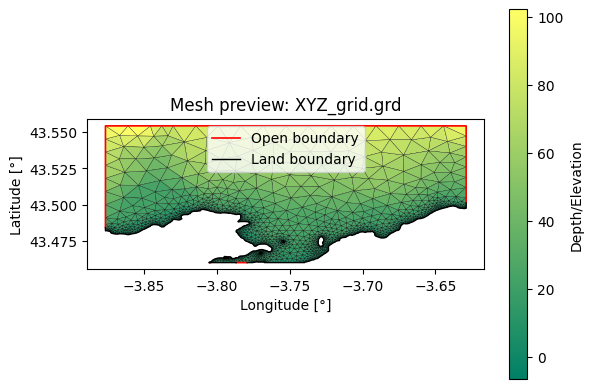

In [37]:
from pymesh2d.geomesh_util.grd_util import plot_grd

plot_grd("XYZ_grid.grd", show_boundaries=True)

---

### References

- **pymesh2D Repository**: [https://github.com/GeoOcean/pymesh2d](https://github.com/GeoOcean/pymesh2d)
- **Original MESH2D**: Darren Engwirda, *Locally-optimal Delaunay-refinement and optimisation-based mesh generation*, Ph.D. Thesis, University of Sydney, 2014 - [https://github.com/dengwirda/mesh2d](https://github.com/dengwirda/mesh2d)